# Huisman–Kemperman two-layer leaky artesian aquifer solution

Extraction from a two-layer leaky artesian aquifer. Source: __Huisman, L. en J. Kemperman (1951) Bemaling van spanningsgrondwater; De Ingenieur 62, pag, 13, 29-35.__

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import timflow.steady as tfs

from bruggeman.other import huisman_kemperman

In [2]:
huisman_kemperman

<function bruggeman.other.huisman_kemperman.huisman_kemperman(r: float | numpy.ndarray[tuple[int, ...], numpy.dtype[numpy.float64]], Q_1: float, Q_2: float, k_1: float, D_1: float, k_2: float, D_2: float, c_1: float, c_2: float) -> tuple[float | numpy.ndarray[tuple[int, ...], numpy.dtype[numpy.float64]], float | numpy.ndarray[tuple[int, ...], numpy.dtype[numpy.float64]]]>

In [3]:
help(huisman_kemperman)

Help on function huisman_kemperman in module bruggeman.other.huisman_kemperman:

huisman_kemperman(
    r: float | numpy.ndarray[tuple[int, ...], numpy.dtype[numpy.float64]],
    Q_1: float,
    Q_2: float,
    k_1: float,
    D_1: float,
    k_2: float,
    D_2: float,
    c_1: float,
    c_2: float
) -> tuple[float | numpy.ndarray[tuple[int, ...], numpy.dtype[numpy.float64]], float | numpy.ndarray[tuple[int, ...], numpy.dtype[numpy.float64]]]
    Head drawdown in the two artesian intervals of a two-layer system.

    Parameters
    ----------
    r : float or NDArray[float64]
        radial distance from the well [L]
    Q_1 : float
        discharge in the upper artesian aquifer [L^3/T]
    Q_2 : float
        discharge in the lower artesian aquifer [L^3/T]
    k_1 : float
        hydraulic conductivity of the upper artesian aquifer [L/T]
    D_1 : float
        thickness of the upper artesian aquifer [L]
    k_2 : float
        hydraulic conductivity of the lower artesian aquifer [

In [4]:
Q_1 = -1600.0  # first-layer discharge [L^3/T]
Q_2 = -2000.0  # second-layer discharge [L^3/T]
k_1 = 20.0  # hydraulic conductivity of first artesian aquifer [L/T]
D_1 = 10.0  # thickness of first artesian aquifer [L]
k_2 = 30.0  # hydraulic conductivity of second artesian aquifer [L/T]
D_2 = 20.0  # thickness of second artesian aquifer [L]
c_1 = 170.0  # leakage resistance above the first artesian aquifer [T]
c_2 = 170.0  # leakage resistance between the two artesian aquifers [T]

In [5]:
# timflow solution
ml = tfs.ModelMaq(
    kaq=[k_1, k_2],
    z=[1, 0, -D_1, -D_1 - 1.0, -D_1 - D_2 - 1.0],
    c=[c_1, c_2],
    topboundary="semi",
    hstar=0.0,
)
w1 = tfs.Well(ml, xw=0, yw=0, Qw=-Q_1, layers=0)
w2 = tfs.Well(ml, xw=0, yw=0, Qw=-Q_2, layers=1)
ml.solve(silent=True)

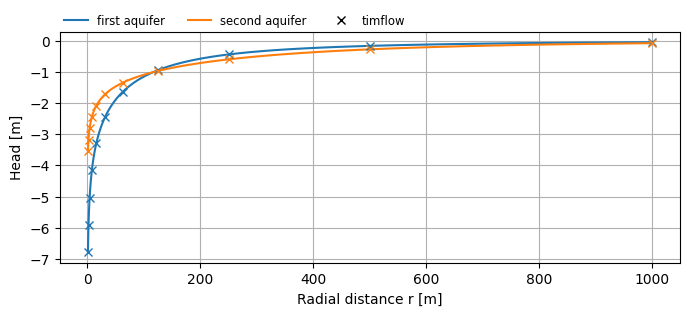

In [ ]:
r = np.logspace(0, 3, 101)
varphi_1, varphi_2 = huisman_kemperman(r, Q_1, Q_2, k_1, D_1, k_2, D_2, c_1, c_2)

h1, h2 = ml.headalongline(r[::10], 0.0)

plt.figure(figsize=(10, 3))
plt.plot(r, varphi_1, label="first aquifer")
plt.plot(r, varphi_2, label="second aquifer")
plt.plot(r[::10], h1, "C0x")
plt.plot(r[::10], h2, "C1x")
plt.plot([], [], "kx", label="timflow")

plt.xlabel("Radial distance r [m]")
plt.ylabel("Head [m]")
plt.grid(True)
plt.legend(loc=(0, 1), frameon=False, ncol=3, fontsize="small");